In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from scipy.spatial import ConvexHull, Delaunay
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import squidpy as sq
import sys
import tifffile as tf
from tqdm import tqdm
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import sample_points_on_square, trunc_graphs, get_mibitof, get_squidpy_visium_datasets
from plotting import add_sig_bar

In [4]:
np.random.seed(41)

In [5]:
try:
    with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
        datasets = pickle.load(f)
except FileNotFoundError:
    datasets = get_mibitof().update(get_squidpy_visium_datasets())
    with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "wb") as f:
        pickle.dump(datasets, f)
            
try:
    all_results = pd.read_csv("/data/bionets/je30bery/truncated_graphs/results/trunc_effects/r_trunc.csv")
except:

    dfs = list()
    for square_limits in [(1/8, 7/8)]:
        df = pd.DataFrame(columns=["data_source", "node density in ROI", "% new edges", "P", "border_size"])
        for dataset in tqdm(datasets):
            coords = datasets[dataset]
            width = np.max(coords[:, 0]) - np.min(coords[:, 0])
            height = np.max(coords[:, 1]) - np.min(coords[:, 1])
            assert width > 0 and height > 0, f"problem, {width}, {height}"
                
            
            xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
            ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 
    
            try:
                out = trunc_graphs(coords=coords, return_graphs=False, method="delaunay", xlim=xlim, ylim=ylim)
                edge_df = out["edge_df"]
            
                old = edge_df.loc[~edge_df["New edge"], "Edge length"]
                new = edge_df.loc[edge_df["New edge"], "Edge length"]
            
                p_mwu = mannwhitneyu(
                    old,
                    new,
                    alternative="two-sided"
                ).pvalue
                data_source = dataset.split(":")[0]
                df.loc[dataset] = [data_source, out["#nodes in ROI"] / (float(height) * float(width)), len(new) / (len(new) + len(old)), p_mwu, square_limits[0]]
            except: # if too few cells are within ROI
                continue
        dfs.append(df)
    
    all_results = pd.concat(dfs)
    all_results["% new edges"] *= 100
    _, all_results["P_adj"], _, _ = multipletests(all_results["P"], alpha=0.05, method="fdr_bh")
    all_results.to_csv("/data/bionets/je30bery/truncated_graphs/results/trunc_effects/del_trunc.csv")

In [6]:
square_limits = (1/8, 7/8)
coords = datasets['glioma_mibitof:Brainiaqc_R1C1_whole_cell.tiff']
width = np.max(coords[:, 0]) - np.min(coords[:, 0])
height = np.max(coords[:, 1]) - np.min(coords[:, 0])

xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 

out = trunc_graphs(coords=coords, return_graphs=True, method="delaunay", xlim=xlim, ylim=ylim)

coords = out["coords"]
subset = out["subset"]

G = out["G"]
subG = out["subG"]
plotG = out["plotG"]
truncG = out["truncG"]

edge_df = out["edge_df"]

In [7]:
p = mannwhitneyu(
    edge_df.loc[~edge_df["New edge"], "Edge length"],
    edge_df.loc[edge_df["New edge"], "Edge length"],
    alternative="two-sided"
).pvalue

In [8]:
ori = edge_df["New edge"].value_counts()[False]
new = len(edge_df) - ori
print(len(truncG.nodes))
print(ori, new, p)

480
1352 68 2.421962074293223e-27


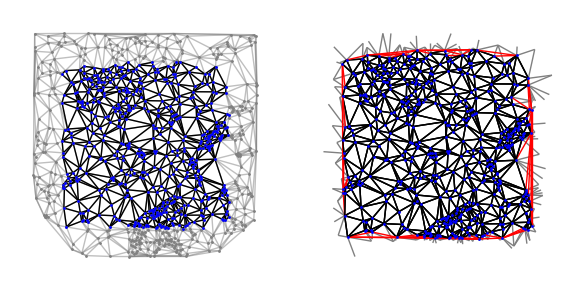

In [9]:
f, axs = plt.subplots(1, 2, figsize=(6, 3))

nx.draw(G, pos=coords, edge_color=(0.5, 0.5, 0.5, 0.5), node_size=1, node_color="gray", ax=axs[0])
nx.draw(subG, node_size=1, pos=coords, node_color="blue", ax=axs[0])

nx.draw_networkx_edges(plotG, pos=coords, ax=axs[1], edge_color="gray")
nx.draw(subG, node_size=1, pos=coords, ax=axs[1], node_color="blue")

edge_colors = [edge in G.edges for edge in truncG.edges]
nx.draw_networkx_edges(truncG, pos=coords, ax=axs[1], edge_color=np.where(edge_colors, "black", "red")) #, node_color=subcoords[:, 2], cmap="magma", vmin=-1, vmax=1)

for ax in axs:
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig("../result_plots/fig2/delaunay_trunc_1.svg")

In [29]:
sources = sorted(list(all_results["data_source"].unique()))
palette = dict(zip(sources, sns.color_palette("magma", len(sources))))

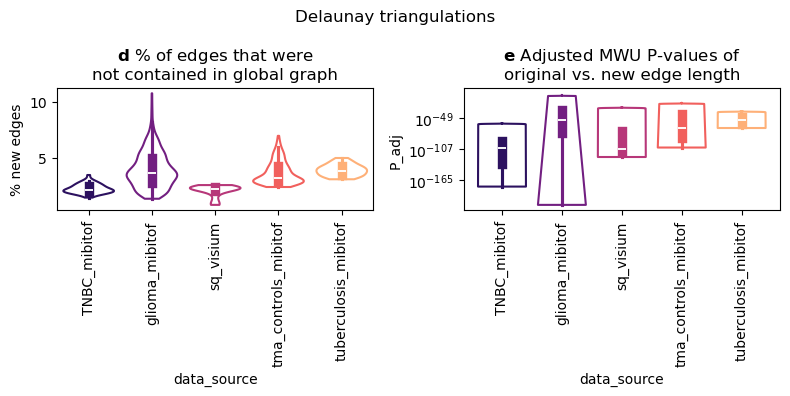

In [37]:
f, axs = plt.subplots(1, 2, figsize=(8, 4))

#sns.violinplot(edge_df, y="Edge length", hue="New edge", cut=0, fill=False, split=True, palette={False: "black", True: "red"}, ax=axs[0], hue_order=[True, False], inner=None)

sns.violinplot(all_results, cut=0, x="data_source", y="% new edges", ax=axs[0], hue="data_source", legend=False, palette=palette, order=sources, fill=False)
sns.violinplot(all_results, cut=0, x="data_source", y="P_adj", ax=axs[1], hue="data_source", legend=False, palette=palette, order=sources, fill=False)
axs[1].hlines(0.001, xmin=0, xmax=all_results["node density in ROI"].max(), color="gray")
axs[1].set_yscale("log")

f.suptitle("Delaunay triangulations")
axs[0].set_title("$\\mathbf{d}$ % of edges that were\nnot contained in global graph")
axs[1].set_title("$\\mathbf{e}$ Adjusted MWU P-values of\noriginal vs. new edge length")
axs[0].tick_params(axis='x', labelrotation=90)
axs[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.savefig("../result_plots/delaunay_trunc.pdf")